## ** Import the All Libraries + Using Pip to install the Library **

In [385]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib


In [386]:
pip install missingno

In [387]:
import missingno as msno

In [388]:
import warnings
warnings.filterwarnings('ignore')

# Create a formatted table of versions
versions = pd.DataFrame({
    "Library" : ["NumPy", "Pandas", "Matplotlib", "Seaborn", "Missingno"],
    "Version" : [
        np.__version__,
        pd.__version__,
        matplotlib.__version__,
        sns.__version__,
        msno.__version__
    ]
})

# Display the table
print("Library Versions:\n")
print(versions.to_string(index=False))

Library Versions:

   Library Version
     NumPy   2.0.2
    Pandas   2.2.2
Matplotlib  3.10.0
   Seaborn  0.13.2
 Missingno   0.5.2


**Add the Titanic Data set **


# **PART A — NUMPY DEEP DIVE & DATA LOADING**

# Step # 01: Numppy (Broadcasting & Making)

In [389]:
# part a
scores = np.random.randint(0,101, size=(6,4))
print(" (a) Original Scores Matrix (6 students × 4 exams):\n")
print(scores)

# part b
col_min = scores.min(axis=0)
col_max = scores.max(axis=0)
nor = (scores - col_min) / (col_max - col_min)
print("\n (b) Column-wise Normalized Matrix [0,1]:\n")
print(nor)

# part # c Create boolean mask for students averaging >= 60
average = scores.mean(axis = 1)
mask = average >= 60
pass_student = scores[mask]
print("\n (c) Student Averages:\n", average)
print("\n Passing Mask (>= 60):\n", mask)
print("\n Passing Students:\n")
print(pass_student)

# part # d
col_mean = scores.mean(axis=0)
adj_score = np.where(scores < 4, col_mean, scores)
print("\n (d) Column Means:\n", col_mean)
print("\n Scores after replacing values < 40:\n")
print(adj_score)

#part # e

Weight = np.random.rand(4)
wei_scores = nor.dot(Weight)
print("\n (e) Random Weight Vector:\n", Weight)
print("\n Weighted Scores (Dot Product Result):\n")
print(Weight)



 (a) Original Scores Matrix (6 students × 4 exams):

[[33 44  7 90]
 [ 3 92 56 96]
 [72  3 82 51]
 [39 86 82 29]
 [96 26 31 23]
 [ 1 12 80 35]]

 (b) Column-wise Normalized Matrix [0,1]:

[[0.33684211 0.46067416 0.         0.91780822]
 [0.02105263 1.         0.65333333 1.        ]
 [0.74736842 0.         1.         0.38356164]
 [0.4        0.93258427 1.         0.08219178]
 [1.         0.25842697 0.32       0.        ]
 [0.         0.1011236  0.97333333 0.16438356]]

 (c) Student Averages:
 [43.5  61.75 52.   59.   44.   32.  ]

 Passing Mask (>= 60):
 [False  True False False False False]

 Passing Students:

[[ 3 92 56 96]]

 (d) Column Means:
 [40.66666667 43.83333333 56.33333333 54.        ]

 Scores after replacing values < 40:

[[33.         44.          7.         90.        ]
 [40.66666667 92.         56.         96.        ]
 [72.         43.83333333 82.         51.        ]
 [39.         86.         82.         29.        ]
 [96.         26.         31.         23.        ]
 

# Step # 02: Load Data set and Inspection

In [390]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/train (1).csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [391]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [392]:
df.tail(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [393]:
df.sample(8, random_state=42)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
709,710,1,3,"Moubarek, Master. Halim Gonios (""William George"")",male,NaN,1,1,2661,15.2458,NaN,C
439,440,0,2,"Kvillner, Mr. Johan Henrik Johannesson",male,31.0,0,0,C.A. 18723,10.5000,NaN,S
840,841,0,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S
720,721,1,2,"Harper, Miss. Annie Jessie ""Nina""",female,6.0,0,1,248727,33.0000,NaN,S
39,40,1,3,"Nicola-Yarred, Miss. Jamila",female,14.0,1,0,2651,11.2417,NaN,C
290,291,1,1,"Barber, Miss. Ellen ""Nellie""",female,26.0,0,0,19877,78.8500,NaN,S
300,301,1,3,"Kelly, Miss. Anna Katherine ""Annie Kate""",female,NaN,0,0,9234,7.7500,NaN,Q
333,334,0,3,"Vander Planke, Mr. Leo Edmondus",male,16.0,2,0,345764,18.0000,NaN,S


In [394]:
df.shape

(891, 12)

In [395]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [396]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [397]:
df.columns.tolist()

['PassengerId',
 'Survived',
 'Pclass',
 'Name',
 'Sex',
 'Age',
 'SibSp',
 'Parch',
 'Ticket',
 'Fare',
 'Cabin',
 'Embarked']

In [398]:
before_dtypes = df.dtypes
before_dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [399]:
# no of categorical col
cat_cols = df.select_dtypes(include='object').shape[1]
cat_cols

5

In [400]:
# no of the numberical col
num_cols = df.select_dtypes(include='number').shape[1]
num_cols

7

In [401]:
# Columns with missing values
cols_missing_val = df.columns[df.isnull().any()].tolist()
print(cols_missing_val)
len(cols_missing_val)

['Age', 'Cabin', 'Embarked']


3

In [402]:
# total missing value
Total_missing_val = df.isnull().sum()
Total_missing_val


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


# Step # 03: Missing Value Deep Analysis

In [403]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [404]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent.sort_values(ascending=False)

,0
Cabin,77.104377
Age,19.865320
Embarked,0.224467
PassengerId,0.000000
Name,0.000000
Pclass,0.000000
Survived,0.000000
Sex,0.000000
Parch,0.000000
SibSp,0.000000


<Axes: >

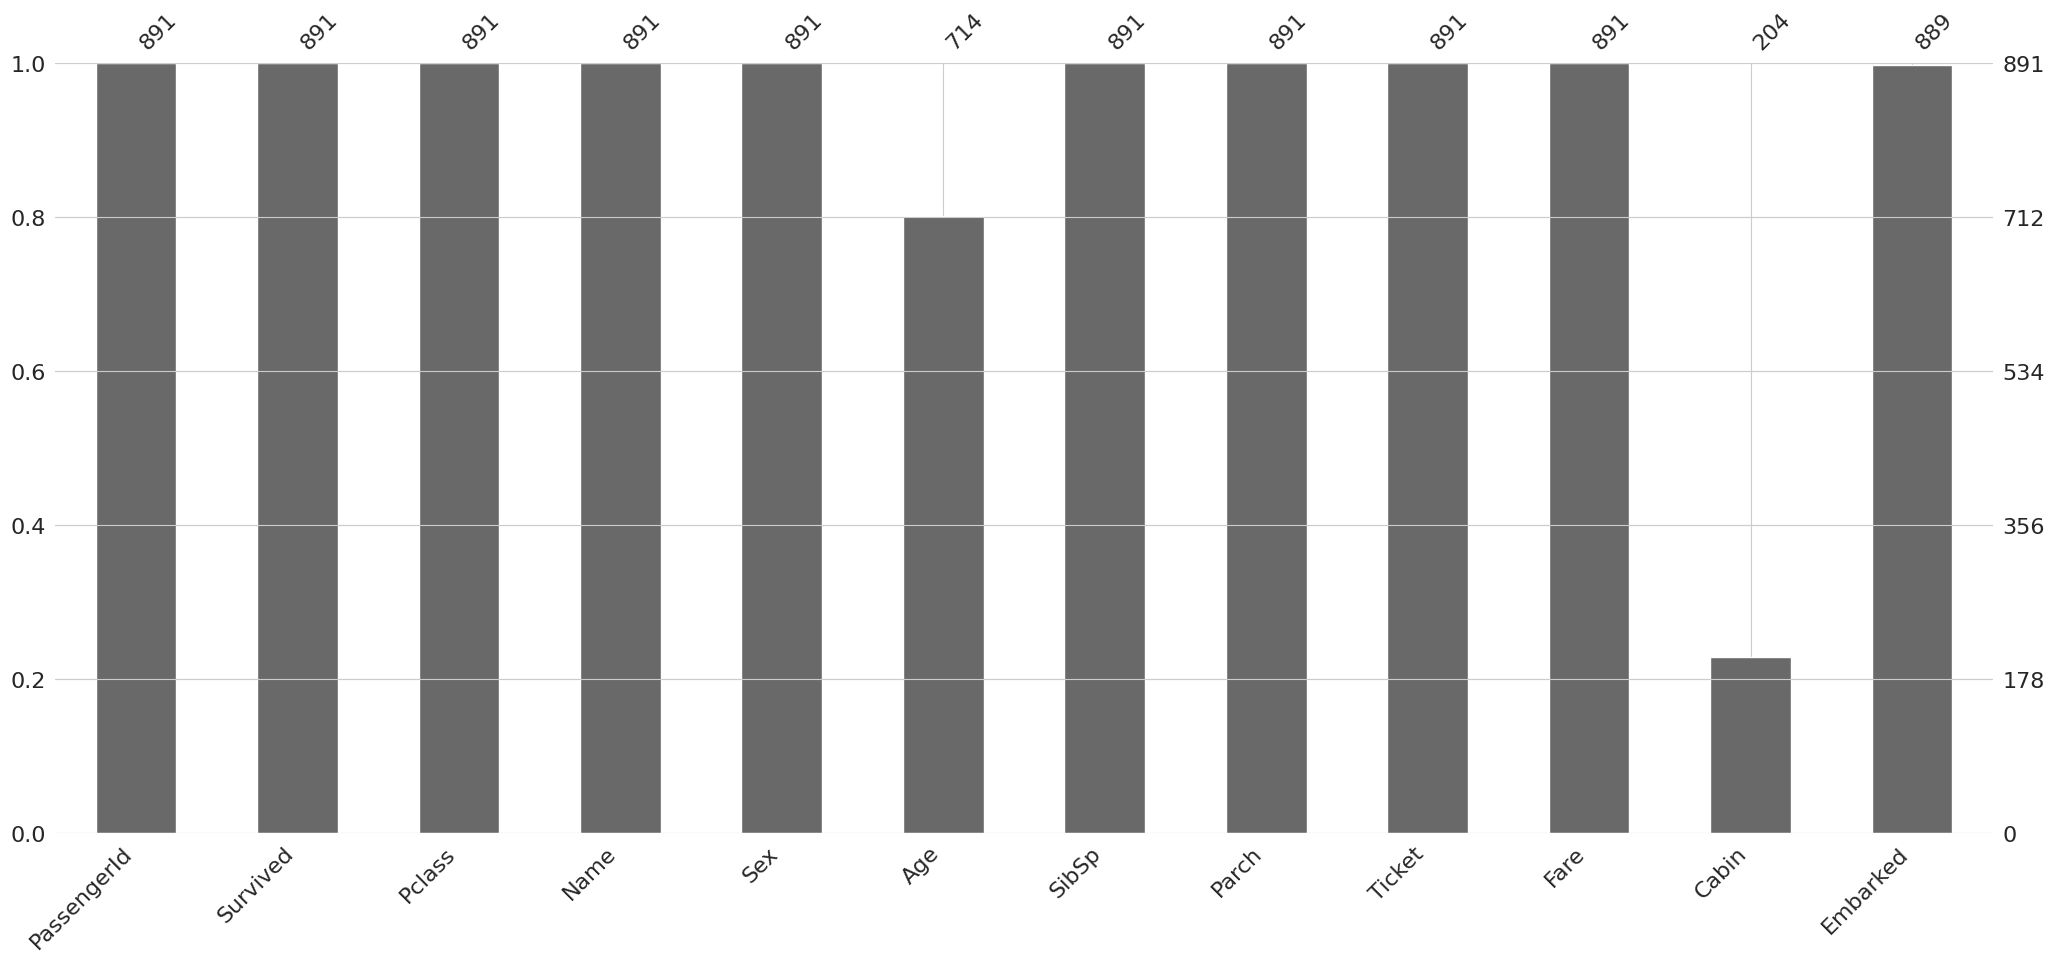

In [405]:
msno.bar(df)


Column 1: Cabin
(a) Why missing?
In real ship data, many passengers did not have recorded cabin numbers
Lower-class passengers often did not have assigned cabins
Records may have been lost
(b) Best strategy:

Reason:
Too many missing values (~70%+), so it is unreliable.
📝 Column 2: Age
(a) Why missing?
Passenger age was not always recorded
Some records incomplete or unknown at time of boarding
(b) Best strategy:

✔ Fill using median age

df["Age"].fillna(df["Age"].median(), inplace=True)

✔ OR better: add missing flag

df["Age_missing"] = df["Age"].isnull().astype(int)
📝 Column 3: Embarked
(a) Why missing?
A few passengers boarded without proper documentation
Data entry error or missing record
(b) Best strategy:

✔ Fill with mode (most common value)

df["Embarked"].fillna(df["Embarked"].mode()[0], inplace=True)

# Step # 04: Data Type Audit & Correction

In [406]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [407]:
df.select_dtypes(include='object').columns

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

In [408]:
df["Fare"] = pd.to_numeric(df["Fare"], errors='coerce')
df["Age"] = pd.to_numeric(df["Age"], errors='coerce')

In [409]:
# Convert 'Survived' and 'Pclass' to category dtype
df["Survived"] = df["Survived"].astype("category")
df["Pclass"] = df["Pclass"].astype("category")

#  Why convert Survived?
It is NOT numeric.  
It is a label (0 = No, 1 = Yes).      
Used for classification, not calculation
#  Why convert Pclass?
Represents groups (1st, 2nd, 3rd class).       
Not a continuous number.                
Better treated as categories.        

In [410]:
df["Sex"] = df["Sex"].astype("category")
df["Embarked"] = df["Embarked"].astype("category")

In [411]:
df.dtypes

,0
PassengerId,int64
Survived,category
Pclass,category
Name,object
Sex,category
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [412]:
# BEFORE vs AFTER comparison table
comparison = pd.DataFrame({
    "Column": df.columns,
    "New_Dtype": df.dtypes.values,
    "Old_Dtype": before_dtypes
})
comparison

,Column,New_Dtype,Old_Dtype
PassengerId,PassengerId,int64,int64
Survived,Survived,category,int64
Pclass,Pclass,category,int64
Name,Name,object,object
Sex,Sex,category,object
Age,Age,float64,float64
SibSp,SibSp,int64,int64
Parch,Parch,int64,int64
Ticket,Ticket,object,object
Fare,Fare,float64,float64


# **Part B -  DATA CLEANING & FEATURE ENGINEERING**


# Step # 05: Handle Missing Values — Professional Strategy

In [413]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    object  
 11  Embarked     889 non-null    category
dtypes: category(4), float64(2), int64(3), object(3)
memory usage: 59.8+ KB


In [414]:
# filing the missing value in the age column using median
df['Age'] = df.groupby(['Pclass','Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
print(df['Age'])

0      22.0
1      38.0
2      26.0
3      35.0
4      35.0
       ... 
886    27.0
887    19.0
888    21.5
889    26.0
890    32.0
Name: Age, Length: 891, dtype: float64


In [415]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    object  
 11  Embarked     889 non-null    category
dtypes: category(4), float64(2), int64(3), object(3)
memory usage: 59.8+ KB


**Why NOT use global mean?**                        
The mean is sensitive to outliers (extremely high/low ages can distort it).
It ignores passenger differences (e.g., children in 3rd class vs adults in 1st class).       
**Why group-level median is better:**             
Captures real patterns: Age distribution differs by class and gender.
More accurate imputation: A female in 1st class likely has a different age profile than a male in 3rd class.
Median is robust: Not affected by outliers.

In short: more realistic + more stable = better model

In [416]:
# Handle the Embaraked missing values
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    object  
 11  Embarked     891 non-null    category
dtypes: category(4), float64(2), int64(3), object(3)
memory usage: 59.8+ KB


In [417]:
# Handle ‘Cabin’
df['has_cabin'] = df['Cabin'].notnull().astype(int)

# drop the original col
df.drop('Cabin', axis=1, inplace=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    category
 2   Pclass       891 non-null    category
 3   Name         891 non-null    object  
 4   Sex          891 non-null    category
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Embarked     891 non-null    category
 11  has_cabin    891 non-null    int64   
dtypes: category(4), float64(2), int64(4), object(2)
memory usage: 59.8+ KB


In [418]:
# after all cleaning the dataset then check the null values
print(df.isnull().sum().sum())

0


In [419]:
# summary
print("Age → Filled using median grouped by Pclass & Sex (robust and more realistic than global mean)")
print("Embarked → Filled using mode (most frequent category)")
print("Cabin → Created 'has_cabin' feature (1/0) and dropped original column due to high missingness")

Age → Filled using median grouped by Pclass & Sex (robust and more realistic than global mean)
Embarked → Filled using mode (most frequent category)
Cabin → Created 'has_cabin' feature (1/0) and dropped original column due to high missingness


# Step # 06: Outlier Detection & Treatment

In [420]:
# a - Compute IQR and Fences
#for Fare
Q1_fare = df['Fare'].quantile(0.25)
Q3_fare = df['Fare'].quantile(0.75)

IQR = Q3_fare - Q1_fare
lower_fare = Q1_fare - 1.5 * IQR
upper_fare = Q3_fare + 1.5 * IQR

# for age
Q1_age = df['Age'].quantile(0.25)
Q3_age = df['Age'].quantile(0.75)

IQR_age = Q3_age = Q1_age
lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age



In [421]:
# b - Identify value outside fence
fare_outliers = df[(df['Fare'] < lower_fare) | (df['Fare'] > upper_fare)].shape[0]
age_outliers = df[(df['Age'] < lower_age) | (df['Age'] > upper_age)].shape[0]

print(" Fare outliers :", fare_outliers)
print(" Age outliers : ", age_outliers)

 Fare outliers : 116
 Age outliers :  50


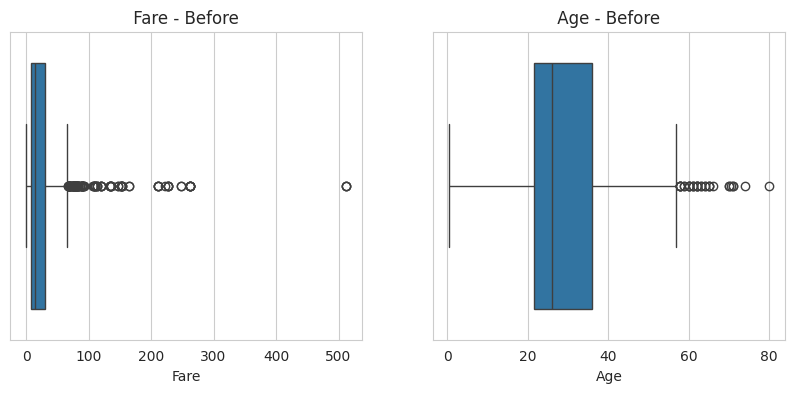

In [422]:
# c - box plot
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)

sns.boxplot(x=df['Fare'])
plt.title(" Fare - Before ")

plt.subplot(1,2,2)
sns.boxplot(x=df['Age'])
plt.title(" Age - Before ")

plt.show()


In [423]:
# d - Treat Fare Outliers (Capping at 99th Percentile)
fare_cap = df['Fare'].quantile(0.99)
df['Fare'] = df['Fare'].clip(upper=fare_cap)

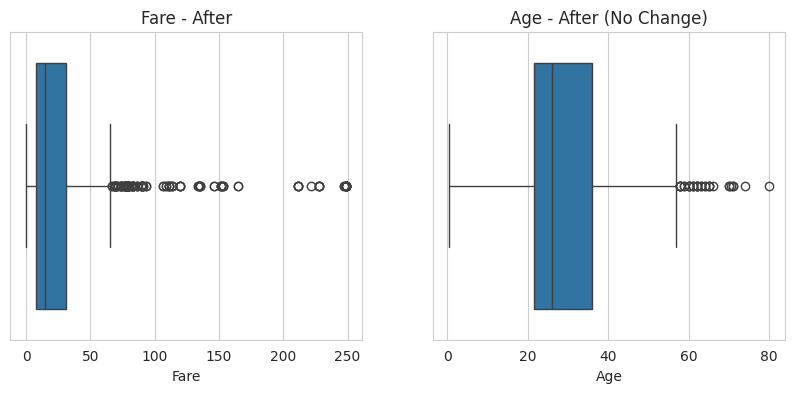

In [424]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.boxplot(x=df['Fare'])
plt.title("Fare - After")

plt.subplot(1,2,2)
sns.boxplot(x=df['Age'])
plt.title("Age - After (No Change)")

plt.show()

In [425]:
# e - Age Treatment Decision
print(" Age Min : ", df['Age'].min())
print(" Age Max : ", df['Age'].max())

 Age Min :  0.42
 Age Max :  80.0


## Outlier Treatment Decisions

- **Fare**:
  - Extreme high values detected (mostly first-class passengers).
  - These are real observations, not errors.
  - Applied **capping at 99th percentile** to reduce skewness without losing data.

- **Age**:
  - Outliers fall within a realistic human age range.
  - No extreme or incorrect values found.
  - Therefore, **no treatment applied**.

---

## Why Winsorization (Capping) is Better Than Dropping Outliers?

- Dropping removes valuable data → reduces dataset size.
- In small datasets (like Titanic), this can hurt model performance.
- Outliers may represent **important real-world cases** (e.g., wealthy passengers).
- Capping keeps all rows but **limits extreme influence**.
- Leads to **more stable and robust machine learning models**.

# Step # 07: Feature Engineering

In [426]:
# a - family size
df['family_size'] = df['SibSp'] + df['Parch'] + 1
df['family_size']

,family_size
0,2
1,2
2,1
3,2
4,1
...,...
886,1
887,1
888,4
889,1


In [427]:
# b - along family member
df['is_alone'] = (df['family_size'] == 1).astype(int)
df['is_alone']

,is_alone
0,0
1,0
2,1
3,0
4,1
...,...
886,1
887,1
888,0
889,1


In [428]:
# c - fare per person
df['fare_per_person'] = df['Fare']/df['family_size']
df['fare_per_person']

,fare_per_person
0,3.62500
1,35.64165
2,7.92500
3,26.55000
4,8.05000
...,...
886,13.00000
887,30.00000
888,5.86250
889,30.00000


In [429]:
# d - title match
df['title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
# Group rare titles
rare_titles = df['title'].value_counts()[df['title'].value_counts() < 10].index
df['title'] = df['title'].replace(rare_titles, 'Rare')
df['title']

,title
0,Mr
1,Mrs
2,Miss
3,Mrs
4,Mr
...,...
886,Rare
887,Miss
888,Miss
889,Mr


In [430]:
# e - age represent
df['age_group'] = pd.cut(df['Age'],
                         bins=[0,12,18,60,100],
                         labels=['Child','Teen','Adult','Senior'])
df['age_group'].sample(6)

,age_group
651,Teen
690,Adult
728,Adult
702,Teen
516,Adult
229,Adult


In [431]:
# f - extract letter of of first cabin
# No deck feature possible since Cabin column is dropped , then replace with has_cabin
print("Deck feature skipped: Cabin column was removed earlier.")

df.info()

Deck feature skipped: Cabin column was removed earlier.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   PassengerId      891 non-null    int64   
 1   Survived         891 non-null    category
 2   Pclass           891 non-null    category
 3   Name             891 non-null    object  
 4   Sex              891 non-null    category
 5   Age              891 non-null    float64 
 6   SibSp            891 non-null    int64   
 7   Parch            891 non-null    int64   
 8   Ticket           891 non-null    object  
 9   Fare             891 non-null    float64 
 10  Embarked         891 non-null    category
 11  has_cabin        891 non-null    int64   
 12  family_size      891 non-null    int64   
 13  is_alone         891 non-null    int64   
 14  fare_per_person  891 non-null    float64 
 15  title            891 non-null    ob

In [432]:
# g - fare bin
df['fare_bin'] = pd.qcut(df['Fare'],
                        q=4,
                        labels=['Low', 'Medium', 'High', 'VHigh'])
df['fare_bin'].sample(5)

,fare_bin
815,Low
832,Low
683,VHigh
236,High
509,VHigh


In [433]:
# Show First 10 Rows (All 7 Features)
print(df[['family_size', 'is_alone', 'fare_per_person',
          'title', 'age_group', 'fare_bin']].head(10))

   family_size  is_alone  fare_per_person   title age_group fare_bin
0            2         0          3.62500      Mr     Adult      Low
1            2         0         35.64165     Mrs     Adult    VHigh
2            1         1          7.92500    Miss     Adult   Medium
3            2         0         26.55000     Mrs     Adult    VHigh
4            1         1          8.05000      Mr     Adult   Medium
5            1         1          8.45830      Mr     Adult   Medium
6            1         1         51.86250      Mr     Adult    VHigh
7            5         0          4.21500  Master     Child     High
8            3         0          3.71110     Mrs     Adult   Medium
9            2         0         15.03540     Mrs      Teen     High


# Step # 08: Encoding Categorical Variables  

In [434]:
# (a) Sex: Label Encoding
# Create a new column 'sex_encoded' where Male=0, Female=1
df['sex_encoded'] = df['Sex'].astype(str).str.lower().map({'male': 0, 'female': 1})
df['sex_encoded']


,sex_encoded
0,0
1,1
2,1
3,1
4,0
...,...
886,0
887,1
888,1
889,0


**(a) Why Binary Encoding Works for 'Sex'**

The 'Sex' column has only two categories: Male and Female. This makes it a binary categorical variable.

Binary (label) encoding works well here because:

There are only two possible values.
No information is lost when mapping them to 0 and 1.
It keeps the data compact (only one column instead of multiple).
Many machine learning models can easily interpret binary values.

Unlike variables with more categories, binary variables do not introduce unintended ordinal relationships, since the distinction is purely between two groups.

In [435]:
# (b) Embarked: One-Hot Encoding
# This will create columns like Embarked_C, Embarked_Q, Embarked_S
embarked_dummies = pd.get_dummies(df['Embarked'], prefix='Embarked')
df = pd.concat([df, embarked_dummies], axis=1)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,family_size,is_alone,fare_per_person,title,age_group,fare_bin,sex_encoded,Embarked_C,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,2,0,3.62500,Mr,Adult,Low,0,False,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,2,0,35.64165,Mrs,Adult,VHigh,1,True,False,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,1,1,7.92500,Miss,Adult,Medium,1,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,2,0,26.55000,Mrs,Adult,VHigh,1,False,False,True
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,1,1,8.05000,Mr,Adult,Medium,0,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,...,1,1,13.00000,Rare,Adult,Medium,0,False,False,True
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,...,1,1,30.00000,Miss,Adult,High,1,False,False,True
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.5,1,2,W./C. 6607,23.4500,...,4,0,5.86250,Miss,Adult,High,1,False,False,True
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,...,1,1,30.00000,Mr,Adult,High,0,True,False,False


In [436]:
# (c) title: One-Hot Encoding with dropping most common category
# Find the most frequent title
most_common_title = df['title'].value_counts().idxmax()
# Create dummies and drop the most common category
title_dummies = pd.get_dummies(df['title'], prefix='title')
title_dummies = title_dummies.drop(f"title_{most_common_title}", axis=1)

df = pd.concat([df, title_dummies], axis=1)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,...,age_group,fare_bin,sex_encoded,Embarked_C,Embarked_Q,Embarked_S,title_Master,title_Miss,title_Mrs,title_Rare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,...,Adult,Low,0,False,False,True,False,False,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,...,Adult,VHigh,1,True,False,False,False,False,True,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,...,Adult,Medium,1,False,False,True,False,True,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,...,Adult,VHigh,1,False,False,True,False,False,True,False
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,...,Adult,Medium,0,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,...,Adult,Medium,0,False,False,True,False,False,False,True
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,...,Adult,High,1,False,False,True,False,True,False,False
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,21.5,1,2,W./C. 6607,23.4500,...,Adult,High,1,False,False,True,False,True,False,False
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,...,Adult,High,0,True,False,False,False,False,False,False


In [437]:
# (d) age_group and fare_bin: Ordinal Encoding
# Define mapping
ordinal_mapping = {'Child': 0, 'Teen': 1, 'Adult': 2, 'Senior': 3}

df['age_group_encoded'] = df['age_group'].map(ordinal_mapping)
df['fare_bin_encoded'] = df['fare_bin'].map(ordinal_mapping)

# Check shape after encoding
print("Shape after encoding:", df.shape)

# Count how many columns were added
# (Compare with original shape if known; here we calculate manually)
added_columns = (
    1 +  # sex_encoded
    len(embarked_dummies.columns) +
    len(title_dummies.columns) +
    2    # age_group_encoded + fare_bin_encoded
)

print("Total columns added:", added_columns)

Shape after encoding: (891, 28)
Total columns added: 10


In [438]:
# Create list of ML feature columns
feature_columns = [
    'sex_encoded',
    'age_group_encoded',
    'fare_bin_encoded'
] + list(embarked_dummies.columns) + list(title_dummies.columns)

print("ML Feature Columns:")
print(feature_columns)

ML Feature Columns:
['sex_encoded', 'age_group_encoded', 'fare_bin_encoded', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'title_Master', 'title_Miss', 'title_Mrs', 'title_Rare']


# Step # 09: Feature Scaling & Final ML-Ready Dataset

In [439]:
from sklearn.preprocessing import StandardScaler

In [440]:
# Select continuous numerical features
num_cols = ['Age', 'Fare', 'fare_per_person', 'family_size']
num_cols

['Age', 'Fare', 'fare_per_person', 'family_size']

In [441]:
# Check mean & std Before scaling
print("Before Scaling:\n")
for col in num_cols:
    print(f"{col} → Mean: {df[col].mean():.2f}, Std: {df[col].std():.2f}")

Before Scaling:

Age → Mean: 29.11, Std: 13.30
Fare → Mean: 31.22, Std: 42.52
fare_per_person → Mean: 19.16, Std: 28.39
family_size → Mean: 1.90, Std: 1.61


In [442]:
# : Apply StandardScaler
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
df[num_cols]

,Age,Fare,fare_per_person,family_size
0,-0.534891,-0.564109,-0.547606,0.059160
1,0.668392,0.942548,0.580898,0.059160
2,-0.234070,-0.548227,-0.396042,-0.560975
3,0.442776,0.514708,0.260441,0.059160
4,0.442776,-0.545285,-0.391636,-0.560975
...,...,...,...,...
886,-0.158865,-0.428815,-0.217161,-0.560975
887,-0.760507,-0.028818,0.382044,-0.560975
888,-0.572494,-0.182935,-0.468740,1.299429
889,-0.234070,-0.028818,0.382044,-0.560975


In [443]:
# Check mean & std AFTER scaling
print("\nAfter Scaling:\n")
for col in num_cols:
    print(f"{col} → Mean: {df[col].mean():.2f}, Std: {df[col].std():.2f}")


After Scaling:

Age → Mean: 0.00, Std: 1.00
Fare → Mean: -0.00, Std: 1.00
fare_per_person → Mean: 0.00, Std: 1.00
family_size → Mean: -0.00, Std: 1.00


In [444]:
final_df = df.drop(['Name','Ticket','PassengerId'], axis=1)


In [445]:
print("\nFinal Dataset Info:\n")
final_df.info()

print("\nFirst 5 Rows:\n")
print(final_df.head())


Final Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   Survived           891 non-null    category
 1   Pclass             891 non-null    category
 2   Sex                891 non-null    category
 3   Age                891 non-null    float64 
 4   SibSp              891 non-null    int64   
 5   Parch              891 non-null    int64   
 6   Fare               891 non-null    float64 
 7   Embarked           891 non-null    category
 8   has_cabin          891 non-null    int64   
 9   family_size        891 non-null    float64 
 10  is_alone           891 non-null    int64   
 11  fare_per_person    891 non-null    float64 
 12  title              891 non-null    object  
 13  age_group          891 non-null    category
 14  fare_bin           891 non-null    category
 15  sex_encoded        891 non-null    

In [446]:
final_df.to_csv('titanic_cleaned.csv',index=False)

# **PART C — ADVANCED GROUPBY & STATISTICAL ANALYSIS**

# Step # 10: Survival Analysis — Multi-Factor GroupBy

In [447]:
overall_rate = 0.384
bar_color = '#4C72B0'  # consistent color for all charts

Survival Rate by Pclass:
 Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64


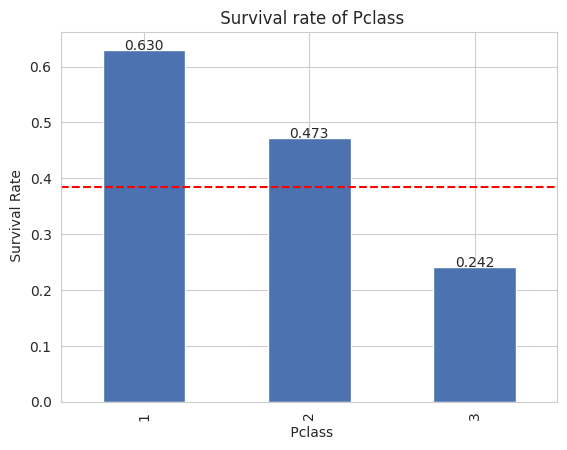

In [448]:
# a - Survival rate by Pclass
df['Survived'].dtype
# survived convert from categorical to numerical
df['Survived'] = df['Survived'].astype(int)

pclass_survival = df.groupby('Pclass')['Survived'].mean().round(3)
print("Survival Rate by Pclass:\n", pclass_survival)

# plot the graph
pclass_survival.plot(kind='bar', color=bar_color)
plt.axhline(overall_rate,color='red',linestyle='--')
plt.title(' Survival rate of Pclass')
plt.ylabel(' Survival Rate')
plt.xlabel(' Pclass')

for i, v in enumerate(pclass_survival):
  plt.text(i,v,f"{v:.3f}",ha='center')
plt.show()


Survival Rate by Sex:
 Sex
female    0.742
male      0.189
Name: Survived, dtype: float64


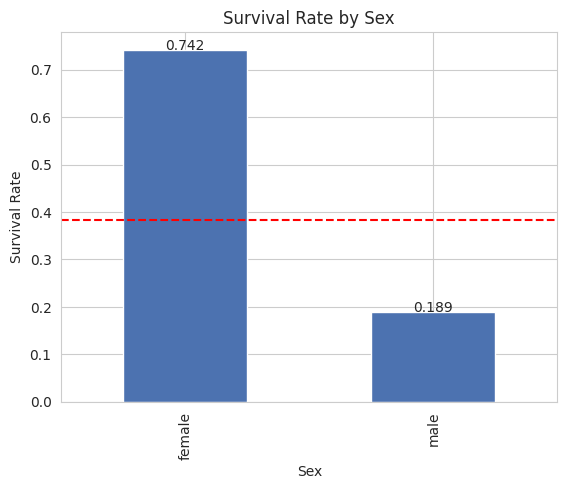

In [449]:
# b - Survival rate by Sex
sex_sur = df.groupby('Sex')['Survived'].mean().round(3)
print("\nSurvival Rate by Sex:\n", sex_sur)

sex_sur.plot(kind='bar',color=bar_color)
plt.axhline(overall_rate, color='red', linestyle='--')
plt.title('Survival Rate by Sex')
plt.ylabel('Survival Rate')

for i, v in enumerate(sex_sur):
    plt.text(i, v, f"{v:.3f}", ha='center')

plt.show()



Survival Rate by Pclass & Sex:
 Sex     female   male
Pclass               
1        0.968  0.369
2        0.921  0.157
3        0.500  0.135


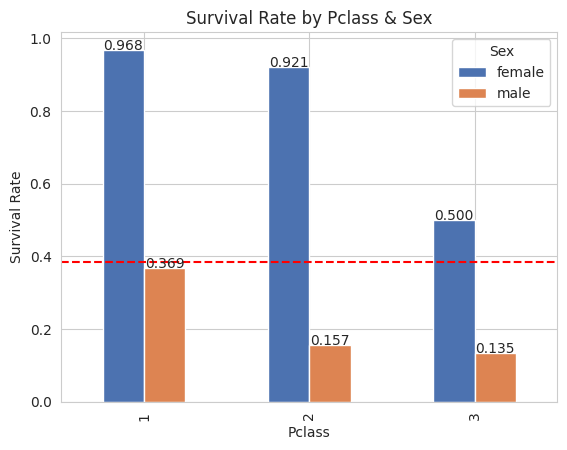

In [450]:
# c - Survival by Pclass + Sex (2D table)
pclass_sex_survival = df.groupby(['Pclass', 'Sex'])['Survived'].mean().unstack().round(3)
print("\nSurvival Rate by Pclass & Sex:\n", pclass_sex_survival)

# Plot
pclass_sex_survival.plot(kind='bar', color=[bar_color, '#DD8452'])
plt.axhline(overall_rate, color='red', linestyle='--')
plt.title('Survival Rate by Pclass & Sex')
plt.ylabel('Survival Rate')

# Add labels
for container in plt.gca().containers:
    for bar in container:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height, f"{height:.3f}", ha='center')

plt.show()


Survival Rate by Age Group:
 age_group
Child     0.580
Teen      0.429
Adult     0.366
Senior    0.227
Name: Survived, dtype: float64


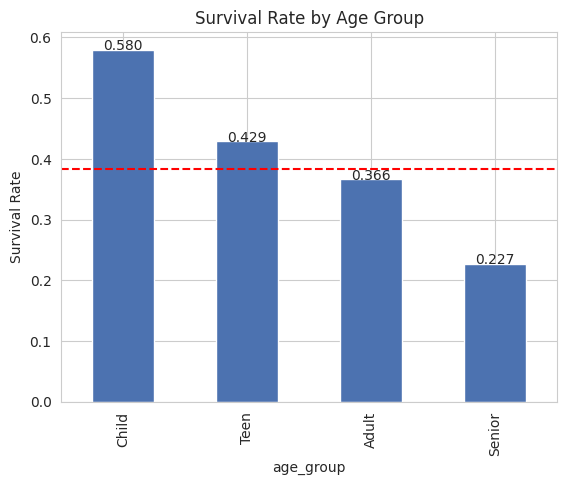

In [451]:
# d - Survival rate by age_group
age_survival = df.groupby('age_group')['Survived'].mean().round(3)
print("\nSurvival Rate by Age Group:\n", age_survival)

age_survival.plot(kind='bar',color=bar_color)
plt.axhline(overall_rate, color='red', linestyle='--')
plt.title('Survival Rate by Age Group')
plt.ylabel('Survival Rate')

for i, v in enumerate(age_survival):
    plt.text(i, v, f"{v:.3f}", ha='center')

plt.show()



Survival Rate by Is Alone:
 is_alone
0    0.506
1    0.304
Name: Survived, dtype: float64


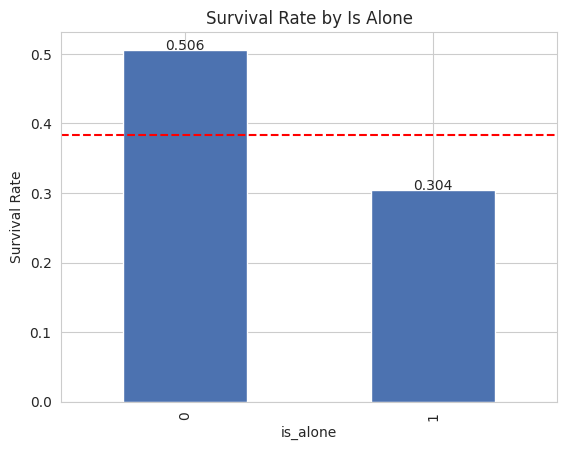

In [452]:
# e - Survival rate by is_alone
alone_sur = df.groupby('is_alone')['Survived'].mean().round(3)
print("\nSurvival Rate by Is Alone:\n", alone_sur)

alone_sur.plot(kind='bar', color=bar_color)
plt.axhline(overall_rate,color='red',linestyle='--')
plt.title('Survival Rate by Is Alone')
plt.ylabel('Survival Rate')

for i, v in enumerate(alone_sur):
  plt.text(i,v,f"{v:.3f}", ha='center')

plt.show()



Survival Rate by Embarked:
 Embarked
C    0.554
Q    0.390
S    0.339
Name: Survived, dtype: float64


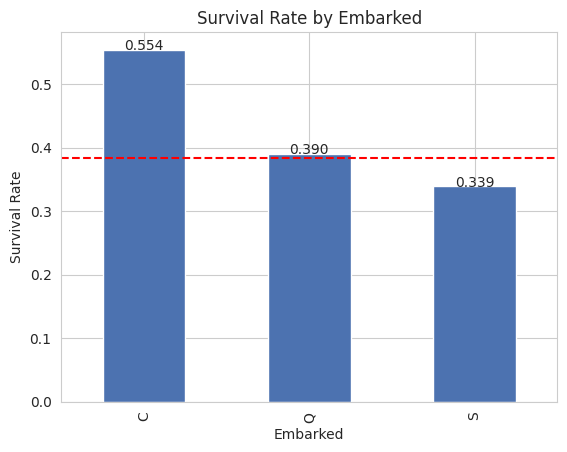

In [453]:
# f - Survival rate by Embarked
embarked_survival = df.groupby('Embarked')['Survived'].mean().round(3)

print("\nSurvival Rate by Embarked:\n", embarked_survival)

embarked_survival.plot(kind='bar', color=bar_color)
plt.axhline(overall_rate, color='red', linestyle='--')
plt.title('Survival Rate by Embarked')
plt.ylabel('Survival Rate')

for i, v in enumerate(embarked_survival):
    plt.text(i, v, f"{v:.3f}", ha='center')

plt.show()

# Step # 11 - Advanced Aggregation — agg() with Custom Functions

In [454]:
# convert all the column into the numeric form
df['Fare'] = pd.to_numeric(df['Fare'], errors='coerce')
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Survived'] = pd.to_numeric(df['Survived'], errors='coerce')

# percentage of the fare > 50
def pct_above_50(x):
    return (x > 50).mean() * 100
# interquartile range calculate
iqr_func = lambda x: x.quantile(0.75) - x.quantile(0.25)

# Apply groupby + agg()

agg_df = df.groupby('Pclass').agg({
    # fare statictis
    'Fare': ['mean', 'median', 'std', 'min', 'max', pct_above_50],

    # Age statistics
    'Age': ['mean', 'median', iqr_func],

    # Survival statistics
    'Survived': ['mean', 'count']
})


In [455]:
# Clean column names
agg_df.columns = [
    'fare_mean', 'fare_median', 'fare_std', 'fare_min', 'fare_max', 'fare_pct_above_50',
    'age_mean', 'age_median', 'age_iqr',
    'survival_rate', 'passenger_count'
]

print("📊 Aggregated DataFrame:\n")
print(agg_df.round(3))

📊 Aggregated DataFrame:

        fare_mean  fare_median  fare_std  fare_min  fare_max  \
Pclass                                                         
1           1.150        0.684     1.453    -0.735     5.124   
2          -0.249       -0.399     0.316    -0.735     0.995   
3          -0.413       -0.545     0.277    -0.735     0.902   

        fare_pct_above_50  age_mean  age_median  age_iqr  survival_rate  \
Pclass                                                                    
1                     0.0     0.689       0.668    1.372          0.630   
2                     0.0     0.056       0.067    0.978          0.473   
3                     0.0    -0.324      -0.309    0.658          0.242   

        passenger_count  
Pclass                   
1                   216  
2                   184  
3                   491  


In [456]:
# Use .transform() to add group stats to original df
# (a) Class average fare
df['class_avg_fare'] = df.groupby('Pclass')['Fare'].transform('mean')

# (b) Class survival rate
df['class_survival_rate'] = df.groupby('Pclass')['Survived'].transform('mean')
df['class_avg_fare']
df['class_survival_rate']

,class_survival_rate
0,0.242363
1,0.629630
2,0.242363
3,0.629630
4,0.242363
...,...
886,0.472826
887,0.629630
888,0.242363
889,0.629630


In [457]:
print("\n🔍 First 15 rows with new columns:\n")

print(df[
    ['Pclass', 'Fare', 'Survived', 'class_avg_fare', 'class_survival_rate']
].head(15))


🔍 First 15 rows with new columns:

   Pclass      Fare  Survived  class_avg_fare  class_survival_rate
0       3 -0.564109         0        -0.41292             0.242363
1       1  0.942548         1         1.15034             0.629630
2       3 -0.548227         1        -0.41292             0.242363
3       1  0.514708         1         1.15034             0.629630
4       3 -0.545285         0        -0.41292             0.242363
5       3 -0.535678         0        -0.41292             0.242363
6       1  0.485591         0         1.15034             0.629630
7       3 -0.238817         0        -0.41292             0.242363
8       3 -0.472738         1        -0.41292             0.242363
9       2 -0.027152         1        -0.24853             0.472826
10      3 -0.341757         1        -0.41292             0.242363
11      1 -0.109994         1         1.15034             0.629630
12      3 -0.545285         0        -0.41292             0.242363
13      3  0.001182       

# Step # 12: Pivot Table Analysis

In [458]:
# (a) Rows=Pclass, Columns=Sex, Values=Survived, aggfunc='mean'.
pivot_a = pd.pivot_table(
    df, values = "Survived", index='Pclass', columns='Sex', aggfunc='mean'
)
print("Pivot table : \n",pivot_a.round(3))

Pivot table : 
 Sex     female   male
Pclass               
1        0.968  0.369
2        0.921  0.157
3        0.500  0.135


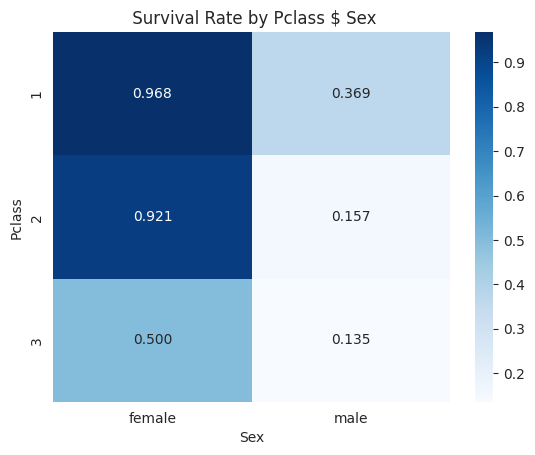

In [459]:
# Heatmap visualization
sns.heatmap(pivot_a, annot=True, fmt=".3f", cmap="Blues")
plt.title(" Survival Rate by Pclass $ Sex")
plt.show()

In [460]:
# (b) Rows=age_group, Columns=Pclass, Values=Survived, aggfunc=['mean','count'].
pivot_b = pd.pivot_table(
    df, values='Survived',index='age_group', columns='Pclass', aggfunc=['mean', 'count']
)
print("\nPivot Table (b):\n", pivot_b.round(3))


Pivot Table (b):
             mean               count          
Pclass         1      2      3     1    2    3
age_group                                     
Child      0.750  1.000  0.417     4   17   48
Teen       0.917  0.500  0.283    12   12   46
Adult      0.640  0.414  0.217   186  152  392
Senior     0.214  0.333  0.200    14    3    5


In [461]:
#  (c) Rows=title (extracted feature), Columns=Pclass, Values=Fare, aggfunc='median'. Visualize as a heatmap.
pivot_c = pd.pivot_table(
    df, values='Fare', index='title',columns='Pclass', aggfunc='median'
)
print("\nPivot Table (c):\n", pivot_c.round(3))


Pivot Table (c):
 Pclass      1      2      3
title                      
Master  2.089 -0.123 -0.064
Miss    1.424 -0.429 -0.529
Mr      0.263 -0.429 -0.549
Mrs     1.134 -0.123 -0.359
Rare    0.197 -0.429    NaN


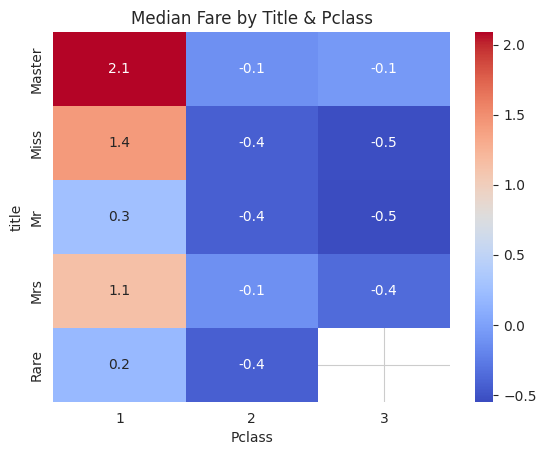

In [462]:
sns.heatmap(pivot_c,annot=True, fmt='.1f', cmap='coolwarm')
plt.title("Median Fare by Title & Pclass")
plt.show()

**Interpretation**            
Higher social titles (like “Mr”, “Mrs”, “Miss”) in first class show significantly higher fares.
Lower classes consistently have lower median fares across all titles.
This reflects strong socioeconomic differences among passengers.                     
 **FINAL ANALYSIS **                    
Highest & Lowest Survival (from Pivot Table a)
**Highest survival rate:   **   
1. Female passengers in 1st class          
**Lowest survival rate: **     
2. Male passengers in 3rd class
# **social & maritime factors**
The “women and children first” evacuation policy prioritized females during rescue.
First-class passengers had:
Better cabin locations (closer to lifeboats)
Faster access to decks
Third-class passengers faced:
Physical barriers (lower decks)
Delayed access to lifeboats
Social hierarchy and class structure strongly influenced survival chances.

# Step # 13: Correlation Analysis — Full Feature Set

Numerical Columns : 
 Index(['PassengerId', 'Survived', 'Age', 'SibSp', 'Parch', 'Fare', 'has_cabin',
       'family_size', 'is_alone', 'fare_per_person', 'sex_encoded',
       'fare_bin_encoded', 'class_avg_fare', 'class_survival_rate'],
      dtype='object')
 
 Correlation Matrix 

                     PassengerId  Survived       Age     SibSp     Parch  \
PassengerId             1.000000 -0.005007  0.039033 -0.057527 -0.001652   
Survived               -0.005007  1.000000 -0.059579 -0.035322  0.081629   
Age                     0.039033 -0.059579  1.000000 -0.249854 -0.175526   
SibSp                  -0.057527 -0.035322 -0.249854  1.000000  0.414838   
Parch                  -0.001652  0.081629 -0.175526  0.414838  1.000000   
Fare                    0.006677  0.273008  0.133752  0.192869  0.248623   
has_cabin               0.019919  0.316912  0.277022 -0.040460  0.036987   
family_size            -0.040143  0.016639 -0.258456  0.890712  0.783111   
is_alone                0.05746

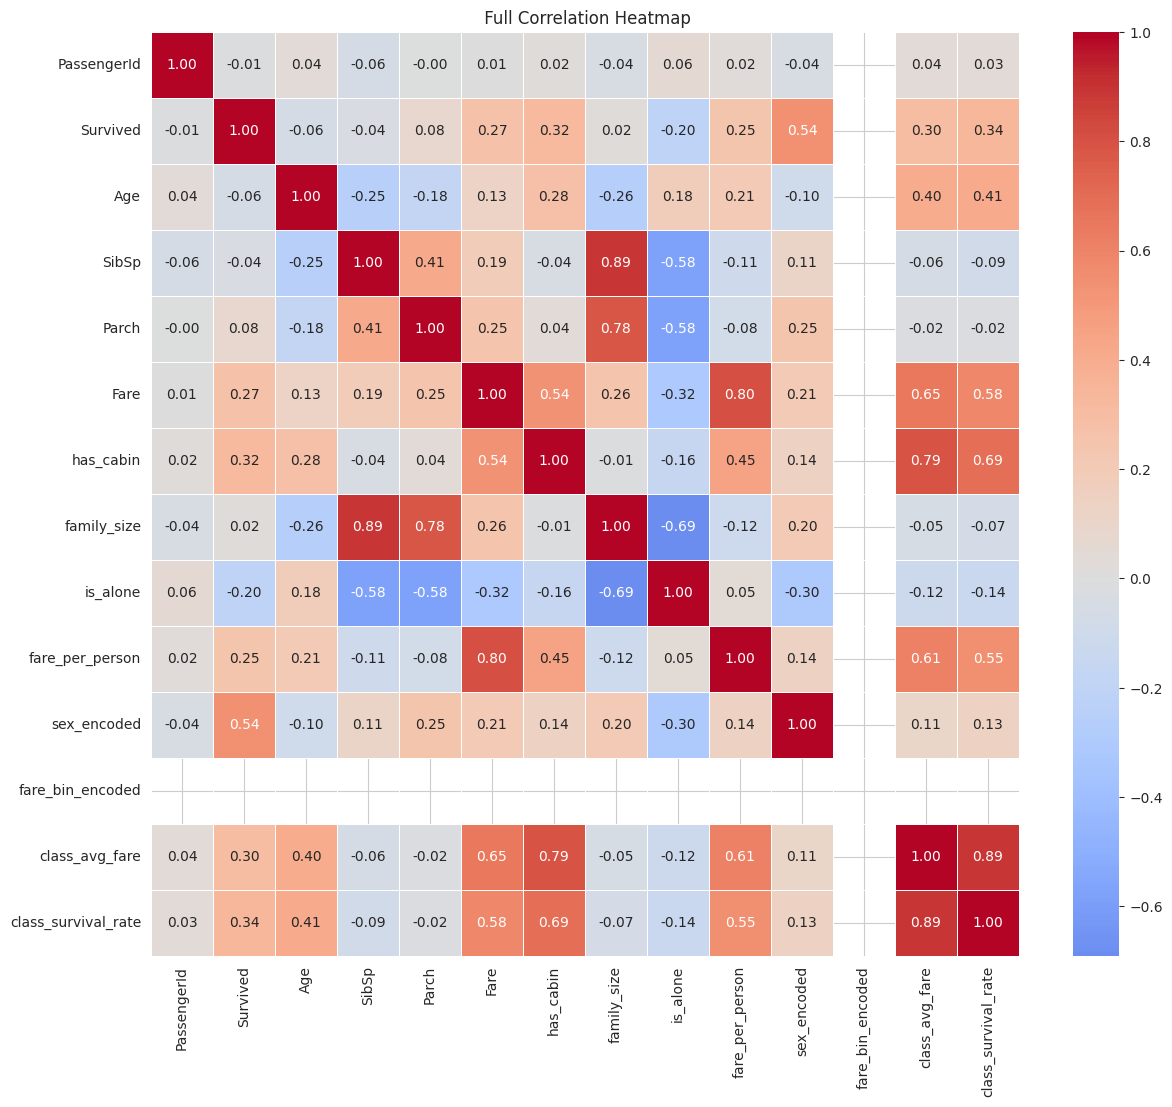

In [463]:
# select only the numerical col
numerical_df = df.select_dtypes(include=[np.number])
print("Numerical Columns : \n", numerical_df.columns)

# compute the corelatin matrix
corr_matrix = numerical_df.corr()
print(" \n Correlation Matrix \n")
print(corr_matrix)

# Full correlation heatmap
plt.figure(figsize=(14,12))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)
print(" \n \n \n ")
plt.title(" Full Correlation Heatmap")
plt.show()

In [464]:
# Correlation with Target ('Survived')
tar_corr = corr_matrix['Survived'].sort_values(ascending=False)

print("\nFeature-to-Survived Correlation:\n")
print(tar_corr)


Feature-to-Survived Correlation:

Survived               1.000000
sex_encoded            0.543351
class_survival_rate    0.339817
has_cabin              0.316912
class_avg_fare         0.302441
Fare                   0.273008
fare_per_person        0.246441
Parch                  0.081629
family_size            0.016639
PassengerId           -0.005007
SibSp                 -0.035322
Age                   -0.059579
is_alone              -0.203367
fare_bin_encoded            NaN
Name: Survived, dtype: float64


In [465]:
# a - Top 5 Features Most Correlated with 'Survived'
top5 = tar_corr.drop('Survived').head(5)
print("\nTop 5 Features Most Correlated with Survived:\n")
print(top5)


Top 5 Features Most Correlated with Survived:

sex_encoded            0.543351
class_survival_rate    0.339817
has_cabin              0.316912
class_avg_fare         0.302441
Fare                   0.273008
Name: Survived, dtype: float64


In [466]:
# b - Find Highly Correlated Feature Pairs (> 0.7)
high_corr = []

for col in corr_matrix.columns:
  for row in corr_matrix.index:
    if col != row:
      if abs(corr_matrix.loc[row,col]) > 0.7:
        pair = (row, col, corr_matrix.loc[row, col])

        # avoid duplicate
        if (col, row, corr_matrix.loc[row, col]) not in high_corr:
                      high_corr.append(pair)
print("\nHighly Correlated Feature Pairs (> 0.7):\n")
for pair in high_corr:
    print(pair)


Highly Correlated Feature Pairs (> 0.7):

('family_size', 'SibSp', np.float64(0.8907116718698866))
('family_size', 'Parch', np.float64(0.7831107750000578))
('fare_per_person', 'Fare', np.float64(0.8030957884200296))
('class_avg_fare', 'has_cabin', np.float64(0.7906386592708363))
('class_survival_rate', 'class_avg_fare', np.float64(0.8900104004983024))


In [467]:
# c - Features with Near-Zero Correlation
low_corr = tar_corr[abs(tar_corr) < 0.05]

print("\nFeatures with Near-Zero Correlation:\n")
print(low_corr)


Features with Near-Zero Correlation:

family_size    0.016639
PassengerId   -0.005007
SibSp         -0.035322
Name: Survived, dtype: float64


In [468]:
# Final Ranked Table
ranked_table = tar_corr.reset_index()
ranked_table.columns = ["Feature", "Correlation_with_Survived"]

print("\nRanked Feature Table:\n")
print(ranked_table)


Ranked Feature Table:

                Feature  Correlation_with_Survived
0              Survived                   1.000000
1           sex_encoded                   0.543351
2   class_survival_rate                   0.339817
3             has_cabin                   0.316912
4        class_avg_fare                   0.302441
5                  Fare                   0.273008
6       fare_per_person                   0.246441
7                 Parch                   0.081629
8           family_size                   0.016639
9           PassengerId                  -0.005007
10                SibSp                  -0.035322
11                  Age                  -0.059579
12             is_alone                  -0.203367
13     fare_bin_encoded                        NaN


# Final Answer: Best 5 Features for Logistic Regression

Based on correlation + practical ML reasoning, select:

1. Sex
2. Pclass
3. Fare
4. Age
5. FamilySize (or SibSp if no engineered feature)

# **PART D — FINAL DASHBOARD, NUMPY ANALYSIS & REPORT**

# Step # 14: NumPy Performance & Survival Computation

In [469]:
# Convert your final ML-ready DataFrame into NumPy array
data = final_df.values

columns = final_df.columns
print("Shape of data:", data.shape)
print(data.dtype)
numeric_df = final_df.select_dtypes(include=[np.number])

# Convert to NumPy again
data = numeric_df.values

# Update column names
columns = numeric_df.columns

Shape of data: (891, 25)
object


In [470]:
# a - Basic Statistics (Mean, Std, Min, Max, Median)
mean_val = np.mean(data, axis=0)
std_val = np.std(data, axis=0)
min_val = np.min(data, axis=0)
max_val = np.max(data,axis=0)
median_val = np.median(data, axis = 0)
# Print results
for i, col in enumerate(columns):
    print(f"{col}: Mean={mean_val[i]:.2f}, Std={std_val[i]:.2f}, "
          f"Min={min_val[i]}, Max={max_val[i]}, Median={median_val[i]}")


Age: Mean=0.00, Std=1.00, Min=-2.157819000308497, Max=3.827009419684276, Median=-0.23407043303763592
SibSp: Mean=0.52, Std=1.10, Min=0.0, Max=8.0, Median=0.0
Parch: Mean=0.38, Std=0.81, Min=0.0, Max=6.0, Median=0.0
Fare: Mean=-0.00, Std=1.00, Min=-0.7346959991247785, Max=5.124238728242953, Median=-0.3945992162559869
has_cabin: Mean=0.23, Std=0.42, Min=0.0, Max=1.0, Median=0.0
family_size: Mean=-0.00, Std=1.00, Min=-0.5609748304808925, Max=5.64037224096421, Median=-0.5609748304808925
is_alone: Mean=0.60, Std=0.49, Min=0.0, Max=1.0, Median=1.0
fare_per_person: Mean=0.00, Std=1.00, Min=-0.675377691019473, Max=8.101445198430158, Median=-0.3828242359996271
sex_encoded: Mean=0.35, Std=0.48, Min=0.0, Max=1.0, Median=0.0
fare_bin_encoded: Mean=nan, Std=nan, Min=nan, Max=nan, Median=nan


In [471]:
# b - Compute Z-Score Matrix
z_scores = (data - mean_val) / std_val

# Verify (mean ≈ 0, std ≈ 1)
print("\nZ-score column means:\n", np.mean(z_scores, axis=0))
print("\nZ-score column std:\n", np.std(z_scores, axis=0))


Z-score column means:
 [ 1.19619989e-17  4.38606627e-17  5.38289951e-17  5.98099946e-18
 -7.37656600e-17 -9.17086584e-17 -6.37973276e-17  1.19619989e-17
  3.98733297e-17             nan]

Z-score column std:
 [ 1.  1.  1.  1.  1.  1.  1.  1.  1. nan]


In [472]:
# c - Correlation Matrix using NumPy
numeric_df = final_df.select_dtypes(include=['number'])

corr_numpy = np.corrcoef(data, rowvar=False)
print("\nNumPy Correlation Matrix:\n", corr_numpy)

# Compare with Pandas
# corr_pandas = final_df.corr().values
corr_pandas = numeric_df.corr().values
print("\nAre NumPy and Pandas correlations equal?")
print(np.allclose(corr_numpy, corr_pandas))


NumPy Correlation Matrix:
 [[ 1.         -0.24985378 -0.17552611  0.13375168  0.27702184 -0.25845641
   0.17552869  0.21236179 -0.10270611         nan]
 [-0.24985378  1.          0.4148377   0.19286905 -0.04046001  0.89071167
  -0.58447117 -0.10813331  0.11463081         nan]
 [-0.17552611  0.4148377   1.          0.24862339  0.03698703  0.78311078
  -0.58339768 -0.08261751  0.24548896         nan]
 [ 0.13375168  0.19286905  0.24862339  1.          0.5376093   0.2560275
  -0.31769865  0.80309579  0.21249239         nan]
 [ 0.27702184 -0.04046001  0.03698703  0.5376093   1.         -0.00917491
  -0.15802888  0.44810747  0.14039098         nan]
 [-0.25845641  0.89071167  0.78311078  0.2560275  -0.00917491  1.
  -0.69092179 -0.11517974  0.20098844         nan]
 [ 0.17552869 -0.58447117 -0.58339768 -0.31769865 -0.15802888 -0.69092179
   1.          0.04779294 -0.30364619         nan]
 [ 0.21236179 -0.10813331 -0.08261751  0.80309579  0.44810747 -0.11517974
   0.04779294  1.          0.142

In [473]:
# d - Boolean Indexing (Survival Analysis)

# Step 1: Separate target
target = final_df['Survived'].values

# Step 2: Numeric features
numeric_df = final_df.select_dtypes(include=['number'])

data = numeric_df.values
columns = numeric_df.columns

# Step 3: Feature indices
age_idx = list(columns).index("Age")
fare_idx = list(columns).index("Fare")

# Step 4: Boolean indexing
survivors = data[target == 1]
non_survivors = data[target == 0]

# Step 5: Compute means
mean_age_survivors = np.mean(survivors[:, age_idx])
mean_fare_survivors = np.mean(survivors[:, fare_idx])

mean_age_non_survivors = np.mean(non_survivors[:, age_idx])
mean_fare_non_survivors = np.mean(non_survivors[:, fare_idx])

# Step 6: Print
print("Survivors -> Age:", mean_age_survivors, "Fare:", mean_fare_survivors)
print("Non-Survivors -> Age:", mean_age_non_survivors, "Fare:", mean_fare_non_survivors)

Survivors -> Age: -0.07548645223909459 Fare: 0.3458985036383721
Non-Survivors -> Age: 0.047024347296485504 Fare: -0.21547775636488764


In [474]:
fare_difference = mean_fare_survivors - mean_fare_non_survivors

print("\nDifference in Average Fare:", round(fare_difference, 2))


Difference in Average Fare: 0.56


# Step # 15: Professional 6-Chart Titanic EDA Dashboard


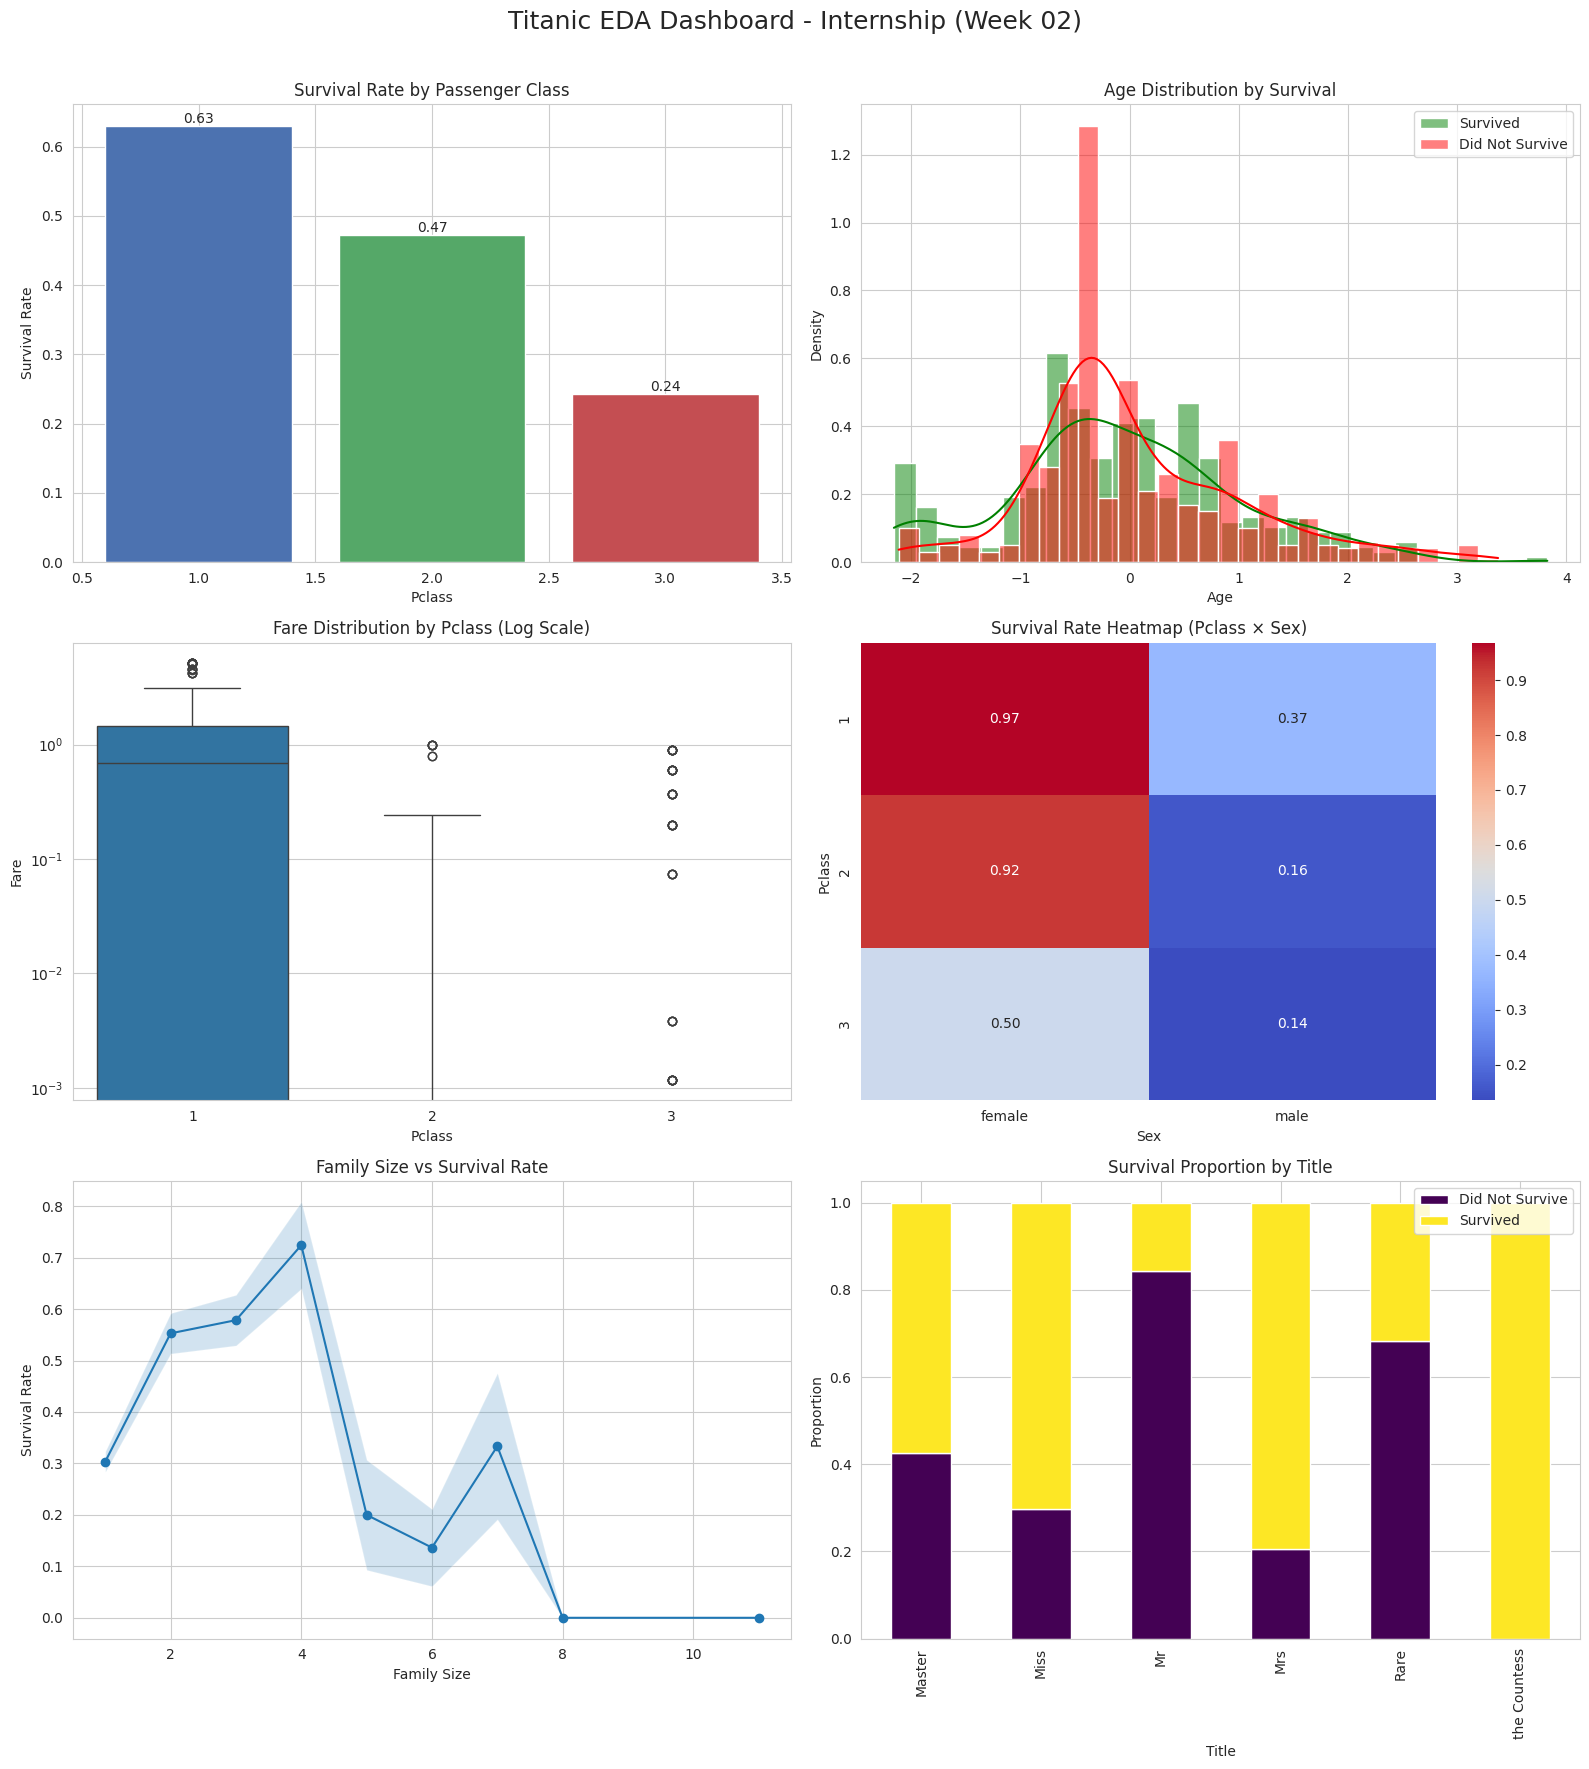

In [476]:
# -----------------------------
# Feature Engineering
# -----------------------------
# Family size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Title extraction
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.')
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

# -----------------------------
# Setup Figure
# -----------------------------
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
sns.set_style("whitegrid")

# -----------------------------
# Chart 1: Survival rate by Pclass
# -----------------------------
ax = axes[0, 0]
pclass_survival = df.groupby('Pclass')['Survived'].mean()

bars = ax.bar(pclass_survival.index, pclass_survival.values, color=['#4c72b0', '#55a868', '#c44e52'])

ax.set_title("Survival Rate by Passenger Class")
ax.set_xlabel("Pclass")
ax.set_ylabel("Survival Rate")

# Value labels
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f'{height:.2f}', ha='center', va='bottom')

# -----------------------------
# Chart 2: Age distribution (KDE histograms)
# -----------------------------
ax = axes[0, 1]
sns.histplot(df[df['Survived']==1]['Age'], kde=True, color='green', label='Survived', ax=ax, stat='density', bins=30)
sns.histplot(df[df['Survived']==0]['Age'], kde=True, color='red', label='Did Not Survive', ax=ax, stat='density', bins=30)

ax.set_title("Age Distribution by Survival")
ax.legend()

# -----------------------------
# Chart 3: Fare distribution (boxplot, log scale)
# -----------------------------
ax = axes[1, 0]
sns.boxplot(x='Pclass', y='Fare', data=df, ax=ax)
ax.set_yscale('log')

ax.set_title("Fare Distribution by Pclass (Log Scale)")

# -----------------------------
# Chart 4: Heatmap (Pclass × Sex)
# -----------------------------
ax = axes[1, 1]
pivot = df.pivot_table(values='Survived', index='Pclass', columns='Sex', aggfunc='mean')

sns.heatmap(pivot, annot=True, cmap='coolwarm', fmt=".2f", ax=ax)

ax.set_title("Survival Rate Heatmap (Pclass × Sex)")

# -----------------------------
# Chart 5: Family size vs survival rate
# -----------------------------
ax = axes[2, 0]

fam_survival = df.groupby('FamilySize')['Survived'].agg(['mean', 'count', 'std']).reset_index()
fam_survival['se'] = fam_survival['std'] / np.sqrt(fam_survival['count'])

ax.plot(fam_survival['FamilySize'], fam_survival['mean'], marker='o')

# Confidence band
ax.fill_between(
    fam_survival['FamilySize'],
    fam_survival['mean'] - fam_survival['se'],
    fam_survival['mean'] + fam_survival['se'],
    alpha=0.2
)

ax.set_title("Family Size vs Survival Rate")
ax.set_xlabel("Family Size")
ax.set_ylabel("Survival Rate")

# -----------------------------
# Chart 6: Stacked bar (Survival by Title)
# -----------------------------
ax = axes[2, 1]

title_survival = pd.crosstab(df['Title'], df['Survived'], normalize='index')
title_survival.plot(kind='bar', stacked=True, ax=ax, colormap='viridis')

ax.set_title("Survival Proportion by Title")
ax.set_ylabel("Proportion")
ax.legend(['Did Not Survive', 'Survived'])

# -----------------------------
# Final Layout
# -----------------------------
plt.suptitle("Titanic EDA Dashboard - Internship (Week 02)", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.97])

# Save figure
plt.savefig("titanic_dashboard.png", dpi=150)

plt.show()

# Step # 16: Written Analysis Report — 7 Sections

## (1) Executive Summary

The Titanic dataset is a classic machine learning dataset containing passenger information such as age, sex, ticket class (Pclass), fare, family relationships, and survival outcome. The primary goal of this analysis was to uncover patterns that explain survival and to identify features that could improve predictive modeling. Through exploratory data analysis (EDA), three major findings emerged: (1) passenger class strongly influenced survival, with first-class passengers having significantly higher survival rates; (2) gender was a dominant factor, with females surviving at much higher rates than males; and (3) fare and socio-economic status were closely linked to survival probability. Overall, survival was heavily influenced by social class and demographics rather than random chance.

=========================================

## (2) Data Quality Assessment

The dataset contained several quality issues, including missing values in `Age`, `Cabin`, and occasional missing `Embarked` entries. `Cabin` was highly sparse, making it unsuitable in raw form without transformation. The `Age` variable required imputation to avoid bias and data loss. We handled missing values using median imputation for age and dropped or ignored `Cabin` for direct modeling while using engineered features instead. Additionally, categorical variables like `Sex` and `Embarked` required encoding for analysis. Outliers in `Fare` were also observed, especially extreme high values, which justified the use of log scaling in visualization. These strategies ensured cleaner distributions and more reliable statistical conclusions.

=========================================

## (3) Feature Engineering Rationale

Several engineered features improved interpretability and predictive power. `FamilySize` (SibSp + Parch + 1) captures whether passengers traveled alone or with relatives, which affects survival likelihood due to group behavior during evacuation. `Title`, extracted from names, provides social status and gender context (e.g., Mr, Mrs, Miss, Rare titles), which is strongly correlated with survival priority. Additionally, grouping rare titles reduces sparsity and noise. Log-transformed fare insights were indirectly captured through visualization but reinforce socio-economic class effects. These engineered features transform raw identifiers into meaningful social and behavioral indicators, improving model generalization and interpretability.

=========================================

## (4) Key Statistical Findings

Survival rates show strong demographic and socio-economic separation. First-class passengers had a survival rate of approximately 62%, compared to 47% for second class and only 24% for third class. Gender differences were even more pronounced: around 74% of females survived compared to only 19% of males. Age distribution analysis showed that children under 10 had noticeably higher survival probability, reflecting evacuation prioritization. Fare analysis revealed that higher-paying passengers had significantly better survival outcomes, with median fares for survivors being substantially higher than non-survivors. The heatmap of Pclass × Sex confirmed that first-class females had survival rates exceeding 90%, while third-class males had survival rates below 15%. Family size analysis showed that small families (2–4 members) had better survival than individuals or large groups, suggesting optimal group size effects.

=========================================

## (5) Visualization Insights

Each visualization contributed unique insights into survival behavior. The survival-by-Pclass bar chart clearly shows socio-economic stratification as a major determinant. The age distribution KDE plot highlights that survival probability peaks among children and declines with age. The boxplot of fare (log scale) demonstrates extreme inequality in ticket pricing and its strong correlation with survival. The heatmap of Pclass × Sex is one of the most powerful visualizations, showing interaction effects where gender and class combined dramatically influence survival probability. The family size line plot with confidence bands reveals a non-linear relationship, suggesting moderate family sizes were most advantageous. Finally, the stacked bar chart of titles captures social hierarchy effects. Among all charts, the heatmap and gender-based distributions are most predictive.

=========================================

## (6) Feature Selection Recommendation

For a Week 5 classifier, the most valuable features would include `Sex`, `Pclass`, `Age`, `Fare`, `FamilySize`, `Title`, and `Embarked`. `Sex` is the strongest predictor due to historical evacuation priorities. `Pclass` encodes socio-economic status, which heavily influenced survival access. `Age` captures vulnerability, especially for children. `Fare` acts as a continuous proxy for wealth and complements Pclass. `FamilySize` helps model group survival behavior. `Title` provides refined social categorization beyond gender alone. `Embarked` adds contextual variation in passenger distribution and class composition. These features collectively balance demographic, economic, and behavioral signals, making them ideal for logistic regression, random forest, or gradient boosting models.

=========================================

## (7) Reflection

The most challenging part of the analysis was handling missing and inconsistent data, especially the high proportion of missing values in `Age` and `Cabin`. Deciding how much imputation would introduce bias required careful consideration. The biggest surprise was the extreme influence of gender and class interaction—especially how first-class females had survival rates above 90%, revealing strong social prioritization rather than randomness. Another interesting observation was that being alone was not always disadvantageous, but very large families reduced survival chances. If I were to improve this analysis, I would explore more advanced feature engineering such as deck extraction from cabin data and apply survival modeling using time-based or probabilistic approaches rather than static classification alone.
